In [1]:
from datasets import *
ds = load_dataset("json", data_files="mgsm_multicolumn_multilang.jsonl", split="train")

In [4]:
import json
from tqdm import tqdm

# Load JSONL file
file_path = "mgsm_multicolumn_multilang.jsonl"
data = []

with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line))

print(f"Loaded {len(data)} examples")


Loaded 250 examples


In [6]:
from sentence_transformers import SentenceTransformer, util

# Load LaBSE model
model = SentenceTransformer('sentence-transformers/LaBSE')

def semantic_similarity(english_sentence, translated_sentence):
    embeddings = model.encode([english_sentence, translated_sentence], convert_to_tensor=True)
    return util.cos_sim(embeddings[0], embeddings[1]).item()

modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

In [12]:
lang_columns = [k for k in data[0].keys() if k.startswith("question_")]

In [26]:
from comet import download_model, load_from_checkpoint

/etc/python/sitecustomize.py:117: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  mod = _original_import(name, globals, locals, fromlist, level)


In [29]:
model_path = download_model("Unbabel/wmt22-cometkiwi-da")

# Load the model
qe_model = load_from_checkpoint(model_path)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

checkpoints/model.ckpt:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

hparams.yaml:   0%|          | 0.00/716 [00:00<?, ?B/s]

.gitattributes:   0%|          | 0.00/1.48k [00:00<?, ?B/s]

Lightning automatically upgraded your loaded checkpoint from v1.8.2 to v2.5.6. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../../../scratch/amahaj56/huggingface/hub/models--Unbabel--wmt22-cometkiwi-da/snapshots/1ad785194e391eebc6c53e2d0776cada8f83179a/checkpoints/model.ckpt`


sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/513 [00:00<?, ?B/s]

Encoder model frozen.
/home/amahaj56/.conda/envs/test/lib/python3.11/site-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


In [32]:
qe_model.eval()

UnifiedMetric(
  (encoder): XLMREncoder(
    (model): XLMRobertaModel(
      (embeddings): XLMRobertaEmbeddings(
        (word_embeddings): Embedding(250002, 1024, padding_idx=1)
        (position_embeddings): Embedding(514, 1024, padding_idx=1)
        (token_type_embeddings): Embedding(1, 1024)
        (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): XLMRobertaEncoder(
        (layer): ModuleList(
          (0-23): 24 x XLMRobertaLayer(
            (attention): XLMRobertaAttention(
              (self): XLMRobertaSdpaSelfAttention(
                (query): Linear(in_features=1024, out_features=1024, bias=True)
                (key): Linear(in_features=1024, out_features=1024, bias=True)
                (value): Linear(in_features=1024, out_features=1024, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): XLMRobertaSelfOutput(
          

In [36]:
scores = {lang_col.split("_")[1]: {"semantic_sum": 0, "adequacy_sum": 0} for lang_col in lang_columns}

# --- Compute scores ---
for item in tqdm(data, desc="Processing examples"):
    english_text = item['question']
    for lang_col in lang_columns:
        lang = lang_col.split("_")[1]
        translated_text = item[lang_col]
        
        # Semantic similarity
        emb = model.encode([english_text, translated_text], convert_to_tensor=True)
        semsim = util.cos_sim(emb[0], emb[1]).item()
        
        # Comet adequacy
        # adequacy = qe_model.predict(english_text, translated_text, batch_size=1)['score'][0].item()
        adequacy = 0
        
        # Accumulate
        scores[lang]["semantic_sum"] += semsim
        scores[lang]["adequacy_sum"] += adequacy
    break

# --- Compute average per language ---
average_scores = []
for lang, val in scores.items():
    avg_sem = val["semantic_sum"] / len(data)
    avg_adeq = val["adequacy_sum"] / len(data)
    average_scores.append({
        "language": lang,
        "avg_semantic_similarity": avg_sem,
        "avg_comet_adequacy": avg_adeq
    })

# --- Convert to DataFrame and save ---
df_avg = pd.DataFrame(average_scores)
# df_avg.to_csv("average_translation_scores.csv", index=False)
# print("Saved average translation scores per language to average_translation_scores.csv")


Processing examples:   0%|          | 0/250 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Processing examples:   0%|          | 0/250 [00:13<?, ?it/s]


In [ ]:
# scores

In [37]:
len(data)

250

In [1]:
import json
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, util
from comet import download_model, load_from_checkpoint
import pandas as pd

# -----------------------------
# Load data
# -----------------------------
file_path = "mgsm_multicolumn_multilang.jsonl"
data = [json.loads(line) for line in open(file_path, "r", encoding="utf-8")]
N = len(data)
print("Loaded", N, "examples")

# -----------------------------
# Load models
# -----------------------------
labse = SentenceTransformer("sentence-transformers/LaBSE")

model_path = download_model("Unbabel/wmt22-cometkiwi-da")
qe = load_from_checkpoint(model_path)
qe.eval()

# -----------------------------
# Extract language columns
# -----------------------------
lang_columns = [k for k in data[0].keys() if k.startswith("question_")]
languages = [col.split("_")[1] for col in lang_columns]

# Score accumulators
scores = {
    lang: {"semantic_sum": 0.0, "adequacy_sum": 0.0}
    for lang in languages
}

# -----------------------------
# STEP 1: Compute ALL LaBSE embeddings first (batched)
# -----------------------------
print("\nComputing LaBSE embeddings...")

# Pre-collect all sentences in consistent order
english_sentences = [item["question"] for item in data]

translated_sentences = {lang: [] for lang in languages}
for item in data:
    for lang, col in zip(languages, lang_columns):
        translated_sentences[lang].append(item[col])

# Encode English only once
eng_emb = labse.encode(english_sentences, batch_size=64, convert_to_tensor=True)

# Encode each language in efficient batches
lang_embs = {}
for lang in tqdm(languages):
    lang_embs[lang] = labse.encode(translated_sentences[lang], batch_size=64, convert_to_tensor=True)

# Compute semantic similarity (no loops over individual items)
for lang in languages:
    sims = util.cos_sim(eng_emb, lang_embs[lang]).diagonal().tolist()
    scores[lang]["semantic_sum"] = sum(sims)

# -----------------------------
# STEP 2: Compute all COMET-Kiwi scores (batched)
# -----------------------------
print("\nComputing COMET-Kiwi scores...")

comet_inputs = []
lang_index_map = []  # (lang, idx) pair for mapping outputs

for lang, col in zip(languages, lang_columns):
    for i in range(N):
        comet_inputs.append({
            "src": data[i]["question"],
            "mt": data[i][col]
        })
        lang_index_map.append((lang, i))

# Run COMET in big batches (change batch_size if needed)
comet_outputs = qe.predict(comet_inputs, batch_size=32)["scores"]

# Accumulate per language
for (lang, _), score in zip(lang_index_map, comet_outputs):
    scores[lang]["adequacy_sum"] += score

# -----------------------------
# STEP 3: Compute averages
# -----------------------------
rows = []
for lang in languages:
    rows.append({
        "language": lang,
        "avg_semantic_similarity": scores[lang]["semantic_sum"] / N,
        "avg_comet_adequacy": scores[lang]["adequacy_sum"] / N
    })

df = pd.DataFrame(rows)
df.to_csv("average_translation_scores.csv", index=False)

print("\nSaved → average_translation_scores.csv")


/etc/python/sitecustomize.py:117: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  mod = _original_import(name, globals, locals, fromlist, level)
/home/amahaj56/.conda/envs/test/lib/python3.11/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Use pytorch device_name: cpu
Load pretrained SentenceTransformer: sentence-transformers/LaBSE


Loaded 250 examples


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Lightning automatically upgraded your loaded checkpoint from v1.8.2 to v2.5.6. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../../../scratch/amahaj56/huggingface/hub/models--Unbabel--wmt22-cometkiwi-da/snapshots/1ad785194e391eebc6c53e2d0776cada8f83179a/checkpoints/model.ckpt`
Encoder model frozen.



Computing LaBSE embeddings...


...

100%|██████████| 95/95 [24:55<00:00, 15.74s/it]
/home/amahaj56/.conda/envs/test/lib/python3.11/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



Computing COMET-Kiwi scores...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
SLURM auto-requeueing enabled. Setting signal handlers.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Predicting DataLoader 0:   5%|▌         | 39/743 [04:57<1:29:34,  7.63s/it]
Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/amahaj56/.conda/envs/test/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [2]:
import pandas as pd
import json
df = pd.read_csv('/home/amahaj56/ondemand/data/sys/myjobs/projects/default/22/average_translation_scores.csv')
file_path = "msvamp_multicolumn_multilang.jsonl"
data = [json.loads(line) for line in open(file_path, "r", encoding="utf-8")][:1]
lang_columns = [k for k in data[0].keys() if k.startswith("m_query_")]
languages = [col.split("_")[2] for col in lang_columns]

In [6]:
# languages

In [3]:
labse_supported = {'af': 'AFRIKAANS',
 'sq': 'ALBANIAN',
 'am': 'AMHARIC',
 'ar': 'ARABIC',
 'hy': 'ARMENIAN',
 'as': 'ASSAMESE',
 'az': 'AZERBAIJANI',
 'eu': 'BASQUE',
 'be': 'BELARUSIAN',
 'bn': 'BENGALI',
 'bs': 'BOSNIAN',
 'bg': 'BULGARIAN',
 'my': 'BURMESE',
 'ca': 'CATALAN',
 'ceb': 'CEBUANO',
 'zh': 'CHINESE',
 'co': 'CORSICAN',
 'hr': 'CROATIAN',
 'cs': 'CZECH',
 'da': 'DANISH',
 'nl': 'DUTCH',
 'en': 'ENGLISH',
 'eo': 'ESPERANTO',
 'et': 'ESTONIAN',
 'fi': 'FINNISH',
 'fr': 'FRENCH',
 'fy': 'FRISIAN',
 'gl': 'GALICIAN',
 'ka': 'GEORGIAN',
 'de': 'GERMAN',
 'el': 'GREEK',
 'gu': 'GUJARATI',
 'ht': 'HAITIAN_CREOLE',
 'ha': 'HAUSA',
 'haw': 'HAWAIIAN',
 'he': 'HEBREW',
 'hi': 'HINDI',
 'hmn': 'HMONG',
 'hu': 'HUNGARIAN',
 'is': 'ICELANDIC',
 'ig': 'IGBO',
 'id': 'INDONESIAN',
 'ga': 'IRISH',
 'it': 'ITALIAN',
 'ja': 'JAPANESE',
 'jv': 'JAVANESE',
 'kn': 'KANNADA',
 'kk': 'KAZAKH',
 'km': 'KHMER',
 'rw': 'KINYARWANDA',
 'ko': 'KOREAN',
 'ku': 'KURDISH',
 'ky': 'KYRGYZ',
 'lo': 'LAOTHIAN',
 'la': 'LATIN',
 'lv': 'LATVIAN',
 'lt': 'LITHUANIAN',
 'lb': 'LUXEMBOURGISH',
 'mk': 'MACEDONIAN',
 'mg': 'MALAGASY',
 'ms': 'MALAY',
 'ml': 'MALAYALAM',
 'mt': 'MALTESE',
 'mi': 'MAORI',
 'mr': 'MARATHI',
 'mn': 'MONGOLIAN',
 'ne': 'NEPALI',
 'no': 'NORWEGIAN',
 'ny': 'NYANJA',
 'or': 'ORIYA',
 'fa': 'PERSIAN',
 'pl': 'POLISH',
 'pt': 'PORTUGUESE',
 'pa': 'PUNJABI',
 'ro': 'ROMANIAN',
 'ru': 'RUSSIAN',
 'sm': 'SAMOAN',
 'gd': 'SCOTS_GAELIC',
 'sr': 'SERBIAN',
 'st': 'SESOTHO',
 'sn': 'SHONA',
 'si': 'SINHALESE',
 'sk': 'SLOVAK',
 'sl': 'SLOVENIAN',
 'so': 'SOMALI',
 'es': 'SPANISH',
 'su': 'SUNDANESE',
 'sw': 'SWAHILI',
 'sv': 'SWEDISH',
 'tl': 'TAGALOG',
 'tg': 'TAJIK',
 'ta': 'TAMIL',
 'tt': 'TATAR',
 'te': 'TELUGU',
 'th': 'THAI',
 'bo': 'TIBETAN',
 'tr': 'TURKISH',
 'tk': 'TURKMEN',
 'ug': 'UIGHUR',
 'uk': 'UKRAINIAN',
 'ur': 'URDU',
 'uz': 'UZBEK',
 'vi': 'VIETNAMESE',
 'cy': 'WELSH',
 'wo': 'WOLOF',
 'xh': 'XHOSA',
 'yi': 'YIDDISH',
 'yo': 'YORUBA',
 'zu': 'ZULU'}

In [4]:
len(labse_supported)

109

In [5]:
len(languages)

0

In [6]:
a = list(labse_supported.keys())
common = list(set(a) & set(languages))
print(common)


[]


In [12]:
len(common)

74

In [13]:
filtered = df[df["language"].isin(common)].sort_values("avg_semantic_similarity")
filtered

,language,avg_semantic_similarity,avg_comet_adequacy
94,yo,0.729750,0.307585
22,bo,0.746030,0.280567
18,as,0.781802,0.816686
53,km,0.829935,0.729975
87,th,0.833665,0.711180
...,...,...,...
45,id,0.920481,0.818487
80,su,0.922236,0.682880
16,af,0.923745,0.790161
31,eo,0.926986,0.831924


In [14]:
# COMET SUPPORTED

In [15]:
la = 'Afrikaans, Albanian, Amharic, Arabic, Armenian, Assamese, Azerbaijani, Basque, Belarusian, Bengali, Bengali Romanized, Bosnian, Breton, Bulgarian, Burmese, Burmese, Catalan, Chinese (Simplified), Chinese (Traditional), Croatian, Czech, Danish, Dutch, English, Esperanto, Estonian, Filipino, Finnish, French, Galician, Georgian, German, Greek, Gujarati, Hausa, Hebrew, Hindi, Hindi Romanized, Hungarian, Icelandic, Indonesian, Irish, Italian, Japanese, Javanese, Kannada, Kazakh, Khmer, Korean, Kurdish (Kurmanji), Kyrgyz, Lao, Latin, Latvian, Lithuanian, Macedonian, Malagasy, Malay, Malayalam, Marathi, Mongolian, Nepali, Norwegian, Oriya, Oromo, Pashto, Persian, Polish, Portuguese, Punjabi, Romanian, Russian, Sanskri, Scottish, Gaelic, Serbian, Sindhi, Sinhala, Slovak, Slovenian, Somali, Spanish, Sundanese, Swahili, Swedish, Tamil, Tamil Romanized, Telugu, Telugu Romanized, Thai, Turkish, Ukrainian, Urdu, Urdu Romanized, Uyghur, Uzbek, Vietnamese, Welsh, Western, Frisian, Xhosa, Yiddish'
la = list(la.split(', '))

In [16]:

mapping = pd.read_csv('fasttext_nllb_mapping_98.csv')
mapping = mapping[(mapping.Duplicate_Flag == False) & (mapping.Missing_Flag == False)]
fasttext = mapping

In [17]:
fasttext

,Ref_Name,fasttext_code,NLLB_Code,Duplicate_Flag,Missing_Flag
0,Tosk Albanian,als,als_Latn,False,False
1,Egyptian Arabic,arz,arz_Arab,False,False
2,Asturian,ast,ast_Latn,False,False
3,South Azerbaijani,azb,azb_Arab,False,False
4,Cebuano,ceb,ceb_Latn,False,False
...,...,...,...,...,...
95,Urdu,ur,urd_Arab,False,False
96,Vietnamese,vi,vie_Latn,False,False
97,Yoruba,yo,yor_Latn,False,False
169,Swahili (macrolanguage),sw,swh_Latn,False,False


In [18]:
filtered_c = fasttext[fasttext["Ref_Name"].str.lower().isin([x.lower() for x in la])]
z = list(filtered_c.fasttext_code)

In [19]:
len(z)

64

In [20]:
filtered_cc = df[df["language"].isin(z)].sort_values("avg_comet_adequacy")

In [21]:
filtered_cc

,language,avg_semantic_similarity,avg_comet_adequacy
77,so,0.877660,0.655871
68,pl,0.839980,0.667537
80,su,0.922236,0.682880
48,jv,0.915787,0.686782
57,lt,0.857062,0.688294
...,...,...,...
39,gu,0.891685,0.837539
50,kn,0.897817,0.841587
21,bn,0.874937,0.849579
97,fr,0.932804,0.863655


<Axes: >

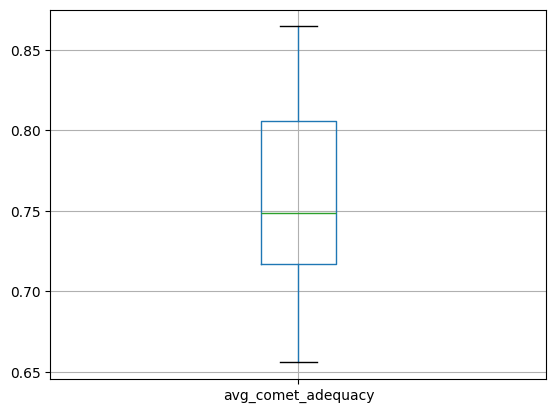

In [25]:
import numpy as np
import matplotlib.pyplot as plt
filtered_cc[["avg_comet_adequacy"]].boxplot()

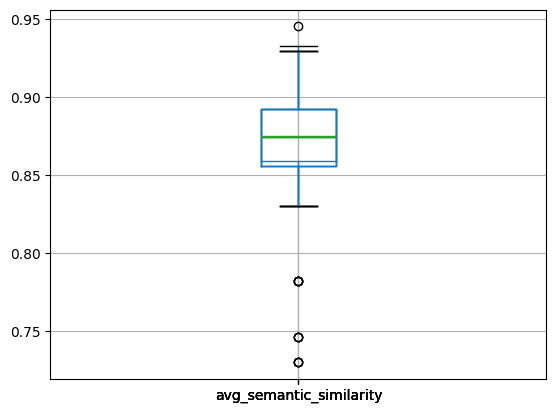

In [31]:
import numpy as np
import matplotlib.pyplot as plt
filtered[["avg_semantic_similarity"]].boxplot()
plt.show()

In [29]:
filtered

,language,avg_semantic_similarity,avg_comet_adequacy
94,yo,0.729750,0.307585
22,bo,0.746030,0.280567
18,as,0.781802,0.816686
53,km,0.829935,0.729975
87,th,0.833665,0.711180
...,...,...,...
45,id,0.920481,0.818487
80,su,0.922236,0.682880
16,af,0.923745,0.790161
31,eo,0.926986,0.831924


In [78]:
filtered_cc.shape

(59, 3)

In [1]:
# SVAMP


import json
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, util
from comet import download_model, load_from_checkpoint
import pandas as pd

# -----------------------------
# Load data
# -----------------------------
file_path = "msvamp_multicolumn_multilang.jsonl"
data = [json.loads(line) for line in open(file_path, "r", encoding="utf-8")][:1]
N = len(data)
print("Loaded", N, "examples")

# -----------------------------
# Load models
# -----------------------------
labse = SentenceTransformer("sentence-transformers/LaBSE")

model_path = download_model("Unbabel/wmt22-cometkiwi-da")
qe = load_from_checkpoint(model_path)
qe.eval()

# -----------------------------
# Extract language columns
# -----------------------------
lang_columns = [k for k in data[0].keys() if k.startswith("m_query_")]
languages = [col.split("_")[2] for col in lang_columns]

# Score accumulators
scores = {
    lang: {"semantic_sum": 0.0, "adequacy_sum": 0.0}
    for lang in languages
}

# -----------------------------
# STEP 1: Compute ALL LaBSE embeddings first (batched)
# -----------------------------
print("\nComputing LaBSE embeddings...")

# Pre-collect all sentences in consistent order
english_sentences = [item["m_query"] for item in data]

translated_sentences = {lang: [] for lang in languages}
for item in data:
    for lang, col in zip(languages, lang_columns):
        translated_sentences[lang].append(item[col])

# Encode English only once
eng_emb = labse.encode(english_sentences, batch_size=64, convert_to_tensor=True)

# Encode each language in efficient batches
lang_embs = {}
for lang in tqdm(languages):
    lang_embs[lang] = labse.encode(translated_sentences[lang], batch_size=64, convert_to_tensor=True)

# Compute semantic similarity (no loops over individual items)
for lang in languages:
    sims = util.cos_sim(eng_emb, lang_embs[lang]).diagonal().tolist()
    scores[lang]["semantic_sum"] = sum(sims)

# -----------------------------
# STEP 2: Compute all COMET-Kiwi scores (batched)
# -----------------------------
print("\nComputing COMET-Kiwi scores...")

comet_inputs = []
lang_index_map = []  # (lang, idx) pair for mapping outputs

for lang, col in zip(languages, lang_columns):
    for i in range(N):
        comet_inputs.append({
            "src": data[i]["m_query"],
            "mt": data[i][col]
        })
        lang_index_map.append((lang, i))

# Run COMET in big batches (change batch_size if needed)
comet_outputs = qe.predict(comet_inputs, batch_size=32)["scores"]

# Accumulate per language
for (lang, _), score in zip(lang_index_map, comet_outputs):
    scores[lang]["adequacy_sum"] += score

# -----------------------------
# STEP 3: Compute averages
# -----------------------------
rows = []
for lang in languages:
    rows.append({
        "language": lang,
        "avg_semantic_similarity": scores[lang]["semantic_sum"] / N,
        "avg_comet_adequacy": scores[lang]["adequacy_sum"] / N
    })

df2 = pd.DataFrame(rows)
df2.to_csv("average_translation_scores_svamp.csv", index=False)

print("\nSaved → average_translation_scores_svamp.csv")


/etc/python/sitecustomize.py:117: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  mod = _original_import(name, globals, locals, fromlist, level)


Loaded 1 examples


/home/amahaj56/.conda/envs/test/lib/python3.11/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Use pytorch device_name: cpu
Load pretrained SentenceTransformer: sentence-transformers/LaBSE


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Lightning automatically upgraded your loaded checkpoint from v1.8.2 to v2.5.6. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../../../scratch/amahaj56/huggingface/hub/models--Unbabel--wmt22-cometkiwi-da/snapshots/1ad785194e391eebc6c53e2d0776cada8f83179a/checkpoints/model.ckpt`
Encoder model frozen.


...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 95/95 [00:05<00:00, 16.11it/s]
/home/amahaj56/.conda/envs/test/lib/python3.11/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
SLURM auto-requeueing enabled. Setting signal handlers.



Computing COMET-Kiwi scores...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Predicting DataLoader 0: 100%|██████████| 3/3 [00:26<00:00,  8.99s/it]



Saved → average_translation_scores_svamp.csv


In [3]:
# scores

In [32]:
#parallel data
1+1

2

In [33]:
from datasets import *
dataset = load_dataset("allenai/dolmino-mix-1124",split="train",streaming = True)

Resolving data files:   0%|          | 0/7352 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/7352 [00:00<?, ?it/s]

In [36]:
first_row = next(iter(dataset))

In [37]:
first_row['text']

'EADS’s decision to change its name to Airbus Group is more than cosmetic. The rebranding symbolically concludes more than four decades of cross-border consolidation while recognizing the formidable power of the Airbus moniker. Given the European aircraft manufacturer’s modest start in 1969-70—when Boeing, Douglas and Lockheed enjoyed a robust near-monopoly worldwide—this switch in names is a remarkable achievement.\n\nHowever, EADS’s top executives, led by Tom Enders, had no plan to mimic Boeing, placing a civil-military portfolio under a unified name. This Airbus Group is adhering to a strictly European strategy that takes into account complex rules peculiar to its European origins. In contrast to Bill Boeing’s legacy, Airbus does not refer to a founding father’s name: the brand was, in essence, created by the popular press. Europe’s plan to develop an innovative high-capacity, short-haul, widebody twinjet was initially christened Galion in a French feasibility study, but the media d

In [39]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import util
from sentence_transformers import SentenceTransformer
import nltk
import torch

In [40]:
cmx_tokenizer = AutoTokenizer.from_pretrained("google/cmx")
cmx_model = AutoModel.from_pretrained("google/cmx")

OSError: google/cmx is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`